In [2]:
from acceptor_TI import Problem, ModelOptions, Geometry, TightBindingBulk

data_path = "../../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [3]:
sub_1 = ["A", "B"]
sub_2 = ["B", "A"]
for sub_label, nn_label in zip(sub_1, sub_2):
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    parser["nn_hopping"][nn_label]["t_ss_sigma"] = 0
    parser["nn_hopping"][nn_label]["t_sp_sigma"] = 0
    parser["nn_hopping"][nn_label]["t_pp_sigma"] = 1
    parser["nn_hopping"][nn_label]["t_pp_pi"] = -1.4

In [4]:
location = "bulk"

# Setup
problem.model_options = ModelOptions(10, 200, location, "reduced")
problem.geometry = Geometry(model_options=problem.model_options, cell_parser=problem.cell_parser)
problem.geometry.build_lattice()

problem.hamiltonian[location]["tight_binding"] = TightBindingBulk(
                model_options=problem.model_options, cell_parser=problem.cell_parser)
tight_binding:TightBindingBulk = problem.hamiltonian[location]["tight_binding"]
tight_binding.orbitals = ['s', 'p_z']
tight_binding.n_orbitals = 2

Building Geometry...
Geometry - Done.


In [5]:
tight_binding.CG_coefficients

{'|0,0;0.5,-0.5>': 0.707106781186548*sqrt(2),
 '|0,0;0.5,0.5>': 0.707106781186548*sqrt(2),
 '|1,-1;0.5,-0.5>': 1.00000000000000,
 '|1,-1;0.5,0.5>': 0.333333333333333*sqrt(3),
 '|1,0;0.5,-0.5>': 0.333333333333333*sqrt(6),
 '|1,0;0.5,0.5>': 0.333333333333333*sqrt(6),
 '|1,1;0.5,-0.5>': 0.333333333333333*sqrt(3),
 '|1,1;0.5,0.5>': 1.00000000000000}

In [ ]:
import numpy as np
from sympy.physics.quantum.cg import CG
def _clebsch_gordan(tb:TightBindingBulk):
        tb.CG_coefficients = {}
        j_2 = 1/2
        m_2 = np.arange(-j_2, j_2 + 1, 1)
        for j_1 in [0, 1]:          
            m_1 = np.arange(-j_1, j_1 + 1, 1)
            j_3 = j_1 + j_2
            m_3 = np.arange(-j_3, j_3 + 1, 1)
            for i, m_j in enumerate(m_3):
                for m_l in m_1:
                    if m_l in [1, -1]: # NOTE: remove p_x and p_y states
                        continue
                    for m_s in m_2:
                        state = f"|{j_1},{m_l};{j_2},{m_s}>"
                        if (m_l + m_s) != m_j:
                            continue
                        tb.CG_coefficients[state] = CG(j_1, m_l, j_2, m_s, j_3, m_j).doit()

In [7]:
_clebsch_gordan(tight_binding)
tight_binding.CG_coefficients

{'|0,0;0.5,-0.5>': 0.707106781186548*sqrt(2),
 '|0,0;0.5,0.5>': 0.707106781186548*sqrt(2),
 '|1,0;0.5,-0.5>': 0.333333333333333*sqrt(6),
 '|1,0;0.5,0.5>': 0.333333333333333*sqrt(6)}

In [8]:
tight_binding.build_hamiltonian(geometry=problem.geometry)

Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


In [9]:
problem.run(
    acceptor=False,
    H_type="reciprocal_space"
)

Calculating 'Bulk' eigenvalues...
'Bulk' Eigenvalues - Done.


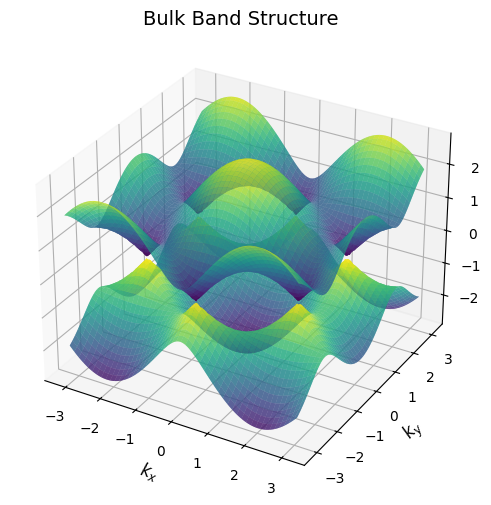

In [10]:
problem.plot(plot_type="dispersion", location=location)